In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import glob
from concurrent.futures import ThreadPoolExecutor
import os

This jupyter notebook calculates and plots the External-Internal Index and the Newman Gender Assortativity Index per year.

In [3]:
authors_df = pd.read_csv('authors_cleaned_V1.csv')

## removing 2020 as well

In [4]:
authors_df = authors_df[authors_df['Publication_Year']<2020]

In [5]:
authors_df.to_csv('authors_cleaned.csv', index=False)

In [6]:
authors_df

,PMID,DescriptorName_UI,LastName,ForeName,AID,ORCID,Journal_JournalIssue_PubDate_MedlineDate,Journal_JournalIssue_PubDate_Year,Publication_Year,Century_Decade,Mention,author_name,Gender
0,11584014,D011471,Fujii,Teruhiko,6757189,NaN,NaN,2002,2002,2000-2010,prostate,Teruhiko Fujii,male
1,11584014,D011471,Wang,Qiming,5191708,NaN,NaN,2002,2002,2000-2010,prostate,Qiming Wang,male
2,11584014,D011471,Blumberg,Peter,3687806,NaN,NaN,2002,2002,2000-2010,prostate,Peter M Blumberg,male
3,11584014,D011471,Ohba,Motoi,8648208,NaN,NaN,2002,2002,2000-2010,prostate,Motoi Ohba,male
4,11584014,D011471,Kuroki,Toshio,2419118,NaN,NaN,2002,2002,2000-2010,prostate,Toshio Kuroki,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213261,28199152,D001943,Hargreaves,Jonathan,6375005,NaN,NaN,2017,2017,2011-2020,breast,Jonathan Hargreaves,male
1213262,28199152,D001943,Elson,Sarah,9419835,NaN,NaN,2017,2017,2011-2020,breast,Sarah L Elson,female
1213263,28199152,D001943,Joe,Bonnie,1351306,NaN,NaN,2017,2017,2011-2020,breast,Bonnie N Joe,female
1213264,28199152,D001943,Feig,Stephen,4908077,NaN,NaN,2017,2017,2011-2020,breast,Stephen A Feig,male


In [ ]:
len(authors_df['AID'])

## define functions

In [7]:
def external_internal_index(coauthorship_graph, authors_df):
    author_gender = {
        (row["LastName"], row["ForeName"]): row["Gender"]
        for _, row in authors_df.iterrows()
    }

    external = 0
    internal = 0

    #iterate over edges and count internal/external edges
    for u, v in coauthorship_graph.edges():
        gender_u = author_gender.get(u, None)
        gender_v = author_gender.get(v, None)

        if gender_u != gender_v:
            external += 1
        else:
            internal += 1

    total_edges = external + internal
    return external / total_edges if total_edges > 0 else 0  #avoid division by zero

In [8]:
def newman_gender_assortativity(coauthorship_graph, authors_df):
    
    author_gender = {
        (row["LastName"], row["ForeName"]): row["Gender"]
        for _, row in authors_df.iterrows()
    }

    nx.set_node_attributes(coauthorship_graph, author_gender, "gender")

    assortativity = nx.attribute_assortativity_coefficient(coauthorship_graph, "gender")

    return assortativity

In [9]:
def analyze_csv(authors_df, disease='prostate', output_folder="output", output_prefix="metrics", year=2021):

    year_df = authors_df[authors_df["Publication_Year"] == year]

    filtered_authors = year_df[year_df["Mention"] == disease]

    filtered_authors_df = filtered_authors[(filtered_authors["Gender"] == 'male') | (filtered_authors["Gender"] == 'female')]
    
    filtered_authors_df = filtered_authors[filtered_authors["Mention"].fillna("").str.lower() == disease.lower()]
    
    if filtered_authors_df.empty:
        print(f"No data for {disease}. Skipping...")
        return

    #create coauthorshp graph
    coauthorship_graph = nx.Graph()

    grouped_authors = filtered_authors_df.groupby("PMID")

    coauthorship_edges = []
    for _, group in grouped_authors:
        authors = group[["LastName", "ForeName"]].apply(tuple, axis=1).tolist()
        coauthorship_edges.extend(itertools.combinations(authors, 2))

    for _, group in grouped_authors:
        for _, row in group.iterrows():
            coauthorship_graph.add_node((row["LastName"], row["ForeName"]), gender=row["Gender"])

    coauthorship_graph.add_edges_from(coauthorship_edges)

    ei_index = external_internal_index(coauthorship_graph, authors_df)

    gender_assortativity = newman_gender_assortativity(coauthorship_graph, authors_df)
    
    return ei_index, gender_assortativity

In [10]:
authors_df[authors_df["Mention"] == 'breast']

,PMID,DescriptorName_UI,LastName,ForeName,AID,ORCID,Journal_JournalIssue_PubDate_MedlineDate,Journal_JournalIssue_PubDate_Year,Publication_Year,Century_Decade,Mention,author_name,Gender
12,11677236,D001943,Kumar-Sinha,Chandan,229498,NaN,NaN,2002,2002,2000-2010,breast,Chandan Kumar-Sinha,male
13,11677236,D001943,Varambally,Sooryanarayana,4568212,NaN,NaN,2002,2002,2000-2010,breast,Sooryanarayana Varambally,male
14,11677236,D001943,Chinnaiyan,Arul,4855464,NaN,NaN,2002,2002,2000-2010,breast,Arul M Chinnaiyan,male
15,11677238,D001943,Kottke,Timothy,6376120,NaN,NaN,2002,2002,2000-2010,breast,Timothy J Kottke,male
16,11677238,D001943,Blajeski,April,7075648,NaN,NaN,2002,2002,2000-2010,breast,April L Blajeski,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213261,28199152,D001943,Hargreaves,Jonathan,6375005,NaN,NaN,2017,2017,2011-2020,breast,Jonathan Hargreaves,male
1213262,28199152,D001943,Elson,Sarah,9419835,NaN,NaN,2017,2017,2011-2020,breast,Sarah L Elson,female
1213263,28199152,D001943,Joe,Bonnie,1351306,NaN,NaN,2017,2017,2011-2020,breast,Bonnie N Joe,female
1213264,28199152,D001943,Feig,Stephen,4908077,NaN,NaN,2017,2017,2011-2020,breast,Stephen A Feig,male


In [11]:
years = authors_df['Publication_Year'].unique()

In [12]:
years

array([2002, 2003, 2004, 2005, 2006, 2007, 2008, 2016, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2017, 2019, 2018])

## calculate EI and Newman

### prostate

In [13]:
data_prostate = []

for year in years:
    EI_index, Newman = analyze_csv(
        authors_df=authors_df, disease='prostate', 
        output_folder="EI_Newman_peryear", output_prefix="metrics", year=year
    )
    data_prostate.append((year, EI_index, Newman))

df_prostate = pd.DataFrame(data_prostate, columns=["Year", "EI_Index", "Newman_Index"])

print(df_prostate)

    Year  EI_Index  Newman_Index
0   2002  0.336939      0.096886
1   2003  0.348616      0.092901
2   2004  0.355905      0.091460
3   2005  0.361847      0.096561
4   2006  0.370642      0.097125
5   2007  0.371247      0.086955
6   2008  0.387746      0.074808
7   2016  0.416413      0.070261
8   2009  0.386528      0.090747
9   2010  0.390580      0.084134
10  2011  0.397404      0.072727
11  2012  0.392401      0.079683
12  2013  0.405436      0.074626
13  2014  0.401241      0.091569
14  2015  0.400305      0.091495
15  2017  0.405547      0.086881
16  2019  0.431118      0.091196
17  2018  0.412699      0.081238


### breast

In [14]:
data_breast = []

for year in years:
    result = analyze_csv(
        authors_df=authors_df, disease='breast', 
        output_folder="EI_Newman_peryear", output_prefix="metrics", year=year
    )
    
    if result is not None:  #some years have no data
        EI_index, Newman = result
        data_breast.append((year, EI_index, Newman))
    else:
        print(f"No valid data for breast cancer in {year}, skipping.")


df_breast = pd.DataFrame(data_breast, columns=["Year", "EI_Index", "Newman_Index"])

print(df_breast)

    Year  EI_Index  Newman_Index
0   2002  0.419121      0.111833
1   2003  0.423295      0.099768
2   2004  0.423795      0.107516
3   2005  0.429783      0.099451
4   2006  0.440386      0.092785
5   2007  0.438799      0.097041
6   2008  0.444025      0.088869
7   2016  0.461288      0.074634
8   2009  0.443918      0.091982
9   2010  0.445812      0.086796
10  2011  0.458924      0.074333
11  2012  0.451435      0.087554
12  2013  0.456132      0.079506
13  2014  0.461934      0.071146
14  2015  0.467699      0.061858
15  2017  0.455409      0.084312
16  2019  0.467515      0.063447
17  2018  0.455048      0.084051


In [15]:
df_breast.to_csv('EI_Newman_data_breast.csv', index=False)
df_prostate.to_csv('EI_Newman_data__prostate.csv', index=False)

In [16]:
df_prostate = df_prostate.sort_values(by='Year')
df_breast = df_breast.sort_values(by='Year')

In [17]:
df_breast

,Year,EI_Index,Newman_Index
0,2002,0.419121,0.111833
1,2003,0.423295,0.099768
2,2004,0.423795,0.107516
3,2005,0.429783,0.099451
4,2006,0.440386,0.092785
5,2007,0.438799,0.097041
6,2008,0.444025,0.088869
8,2009,0.443918,0.091982
9,2010,0.445812,0.086796
10,2011,0.458924,0.074333


In [18]:
df_prostate

,Year,EI_Index,Newman_Index
0,2002,0.336939,0.096886
1,2003,0.348616,0.092901
2,2004,0.355905,0.091460
3,2005,0.361847,0.096561
4,2006,0.370642,0.097125
5,2007,0.371247,0.086955
6,2008,0.387746,0.074808
8,2009,0.386528,0.090747
9,2010,0.390580,0.084134
10,2011,0.397404,0.072727


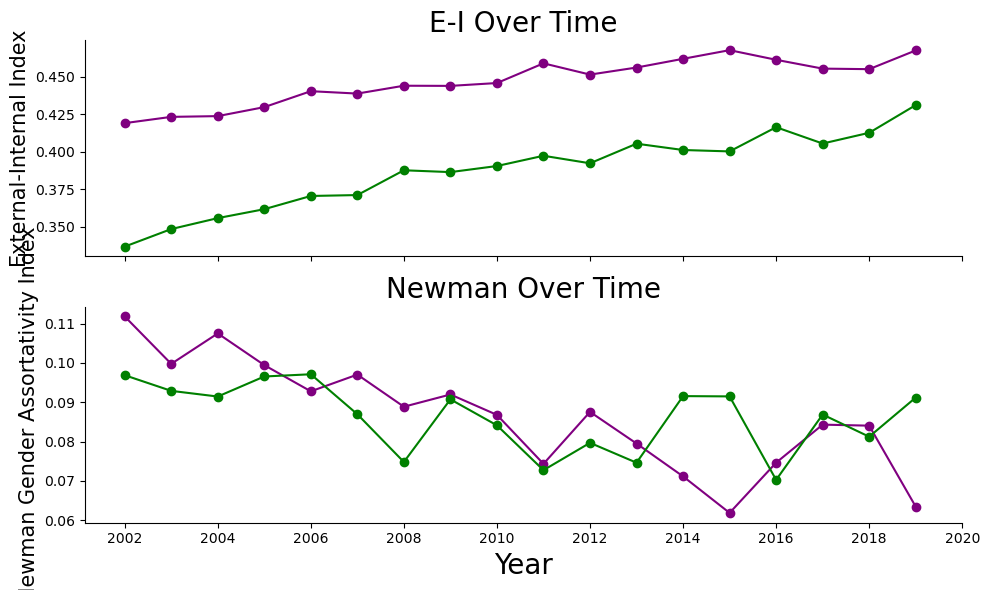

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Color definitions for consistency
breast_color = 'purple'
prostate_color = 'green'

# EI plot (top subplot)
ax1 = plt.subplot(2, 1, 1)
l1, = ax1.plot(df_breast['Year'], df_breast['EI_Index'], label='Breast Cancer', marker='o', color=breast_color)
l2, = ax1.plot(df_prostate['Year'], df_prostate['EI_Index'], label='Prostate Cancer', marker='o', color=prostate_color)
ax1.set_title('E-I Over Time', fontsize=20)
ax1.set_ylabel('External-Internal Index', fontsize=15)
ax1.set_xticks(np.arange(2002, 2022, 2))
ax1.set_xticklabels([])  # Hide x-axis labels on top plot

# Newman plot (bottom subplot)
ax2 = plt.subplot(2, 1, 2)
l3, = ax2.plot(df_breast['Year'], df_breast['Newman_Index'], marker='o', color=breast_color)
l4, = ax2.plot(df_prostate['Year'], df_prostate['Newman_Index'], marker='o', color=prostate_color)
ax2.set_title('Newman Over Time', fontsize=20)
ax2.set_xlabel('Year', fontsize=20)
ax2.set_ylabel('Newman Gender Assortativity Index', fontsize=15)
ax2.set_xticks(np.arange(2002, 2022, 2))

# Remove boxes/spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# One legend for all
#plt.legend([l1, l2], ['Breast Cancer', 'Prostate Cancer'], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.tight_layout()
plt.savefig('metrics_over_time.png', bbox_inches='tight')
plt.show()


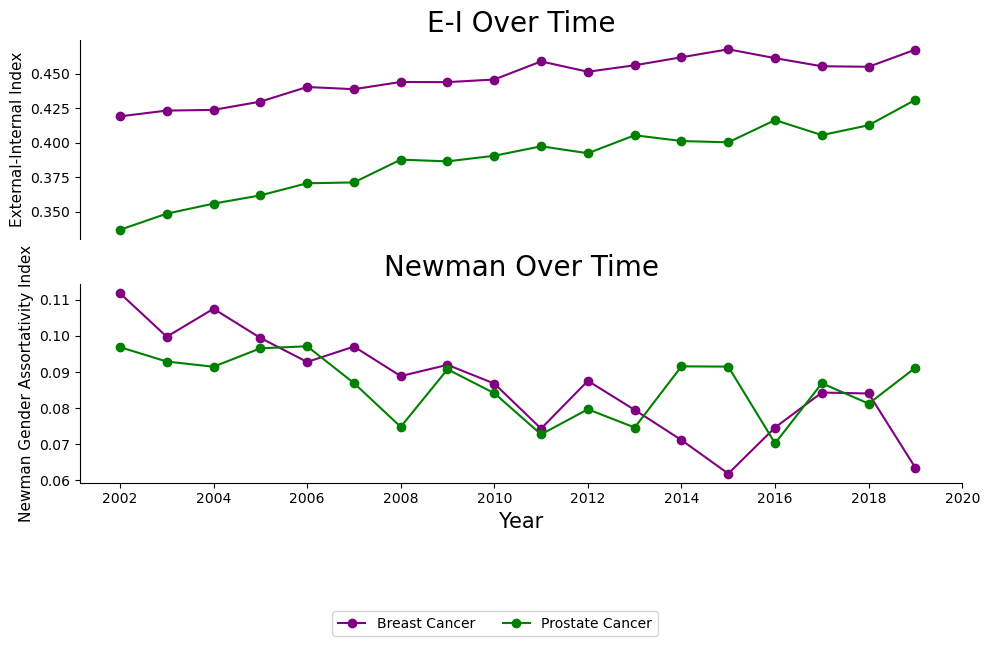

In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plotting data
l1, = ax1.plot(df_breast['Year'], df_breast['EI_Index'], label='Breast Cancer', marker='o', color='purple')
l2, = ax1.plot(df_prostate['Year'], df_prostate['EI_Index'], label='Prostate Cancer', marker='o', color='green')
ax1.set_title('E-I Over Time', fontsize=20)
ax1.set_ylabel('External-Internal Index', fontsize=11)

l3, = ax2.plot(df_breast['Year'], df_breast['Newman_Index'], marker='o', color='purple')
l4, = ax2.plot(df_prostate['Year'], df_prostate['Newman_Index'], marker='o', color='green')
ax2.set_title('Newman Over Time', fontsize=20)
ax2.set_xlabel('Year', fontsize=15)
ax2.set_ylabel('Newman Gender Assortativity Index', fontsize=11)

# Set x-ticks only on bottom plot
ax2.set_xticks(np.arange(2002, 2022, 2))
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Remove spines (boxes)
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax1.spines['bottom'].set_visible(False)

# Legend outside the plot
fig.legend([l1, l2], ['Breast Cancer', 'Prostate Cancer'],
           loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=2)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # Make space for the legend
plt.savefig('metrics_over_time.png', bbox_inches='tight')
plt.show()
